## 数据导入和整理

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from STATS import *
name = '总体'
if name == '总体':
    data_us = pd.read_excel('data/美股'+name+'日数据.xls').dropna()
    data_china = pd.read_excel('data/A股'+name+'日数据.xls').dropna()
else:
    data_us = pd.read_excel('data/美股'+name+'日数据.xlsx').dropna()
    data_china = pd.read_excel('data/A股'+name+'日数据.xlsx').dropna()
date_name_us = '日期'
date_name_china = '日期'
value_name_us = '收盘价(总股本加权平均)\n[单位] 元'
value_name_china = '收盘价(总股本加权平均)\n[单位] 元'
# data_inter = pd.read_excel('data/international.xlsx')
# data_china = pd.read_excel('data/domestic.xlsx')

In [23]:
# data_us = data_inter[data_inter['Indexcd'].str.contains('DJI',na=False)]
data_us[date_name_us] = pd.to_datetime(data_us[date_name_us])
data_china[date_name_china] = pd.to_datetime(data_china[date_name_china])
common_values = set(data_us[date_name_us]) & set(data_china[date_name_china])
data_us = data_us[data_us[date_name_us].isin(common_values)]
data_china = data_china[data_china[date_name_china].isin(common_values)]
data_us.set_index(date_name_us, inplace=True) 
data_china.set_index(date_name_china, inplace=True)
list_us = np.array(data_us[value_name_us].to_list())
list_china =np.array( data_china[value_name_china].to_list())

In [24]:
r_us = np.log(list_us[1:] / list_us[:-1])
r_china = np.log(list_china[1:] / list_china[:-1])

## 统计分析和检验

In [25]:
basic_us = analyze_basic_stats(r_us)
basic_china = analyze_basic_stats(r_china)
self_test_us = test_serial_dependence(r_us)
self_test_china = test_serial_dependence(r_china)
self_test_us = {f'{k}_1': v for k, v in self_test_us.items()}
self_test_china = {f'{k}_1': v for k, v in self_test_china.items()}
stats_basic = pd.DataFrame([basic_us, basic_china], index=['US', 'China'])
stats_self_1 = pd.DataFrame([self_test_us, self_test_china], index=['US', 'China'])
stats = pd.concat([stats_basic, pd.DataFrame(stats_self_1)], axis=1)
stats

,Mean,Variance,Skewness,Kurtosis,ADF Statistic,ADF p-value,JB Statistic,JB p-value,Ljung–Box Q Statistic_1,Ljung–Box Q p-value_1,ARCH LM Statistic_1,ARCH LM p-value_1
US,0.000365,0.000210,-0.987531,18.795414,-7.533585,3.525945e-11,14301.620983,0.000000e+00,234.381285,1.035286e-44,387.826733,3.662008e-77
China,0.000276,0.000174,-0.493337,3.691809,-31.004390,0.000000e+00,584.727696,1.066582e-127,2.962073,9.823025e-01,19.960539,2.962814e-02


## VAR自回归

In [26]:
var_model, lag_order = bivariate_var_analysis(r_us,r_china, maxlags=15)

选出的最优滞后阶数 (by AIC): 9

模型摘要：
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 24, May, 2025
Time:                     11:29:46
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -17.0694
Nobs:                     952.000    HQIC:                  -17.1894
Log likelihood:           5553.67    FPE:                3.18164e-08
AIC:                     -17.2633    Det(Omega_mle):     3.05835e-08
--------------------------------------------------------------------
Results for equation Series1
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const              0.000324         0.000442            0.732           0.464
L1.Series1        -0.109880         0.033108           -3.319           0.001
L1.Series2         0.006055         0.034

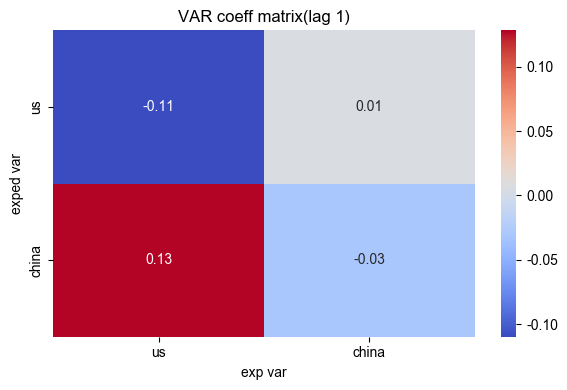

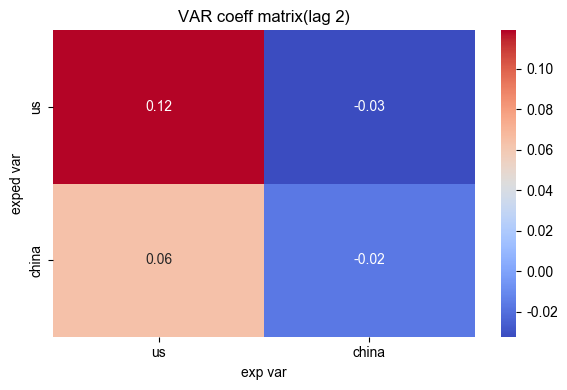

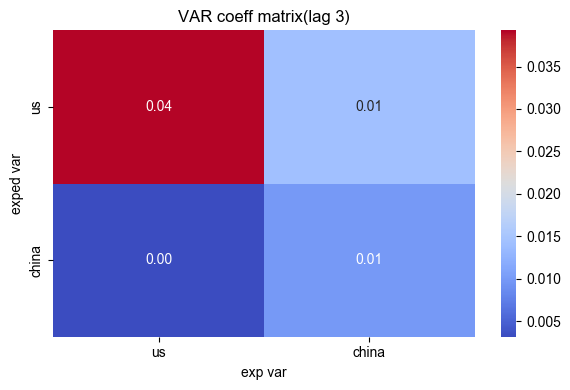

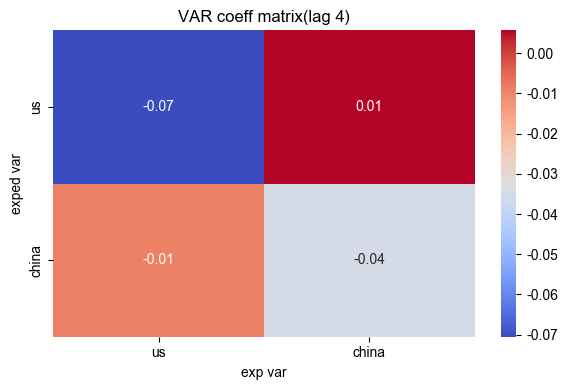

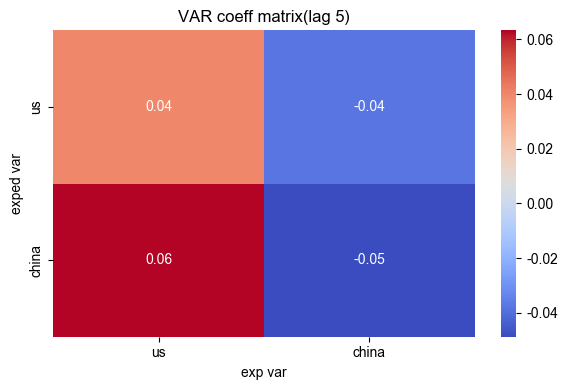

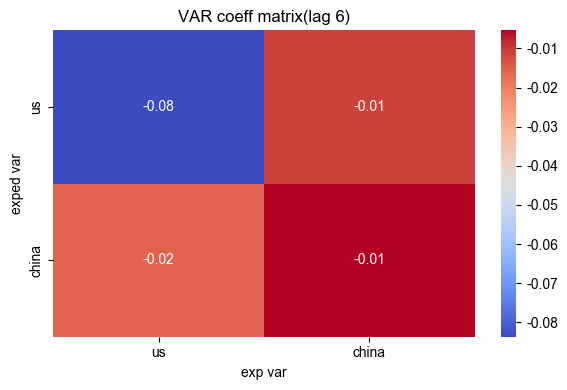

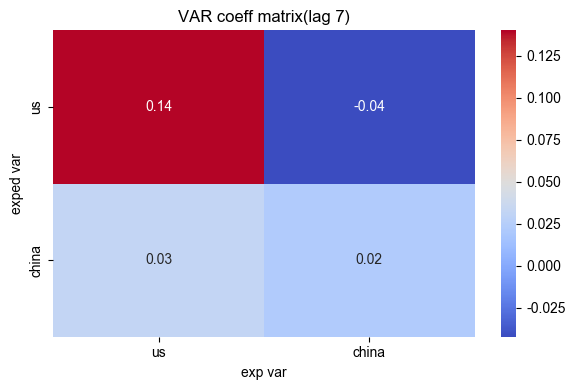

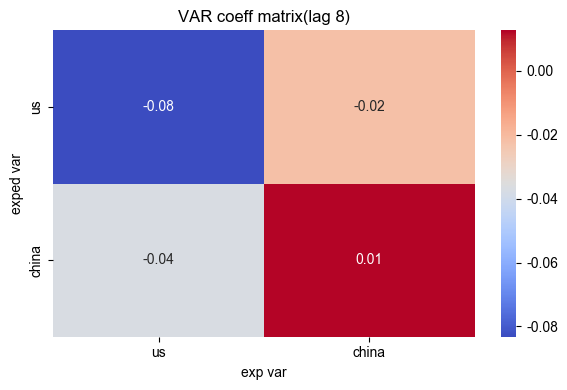

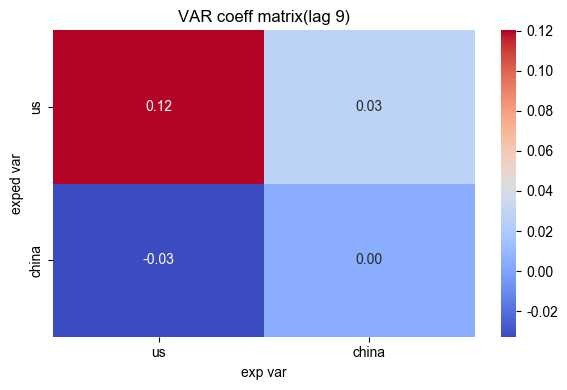

In [27]:
import seaborn as sns
coefs = var_model.coefs 
name1 = ('us','china')
for i, coef_matrix in enumerate(coefs):
    plt.figure(figsize=(6, 4))
    sns.heatmap(coef_matrix, annot=True, fmt=".2f", cmap="coolwarm",
                xticklabels=name1, yticklabels=name1)
    plt.title(f"VAR coeff matrix(lag {i+1})")
    plt.xlabel("exp var")
    plt.ylabel("exped var")
    plt.tight_layout()
    plt.show()

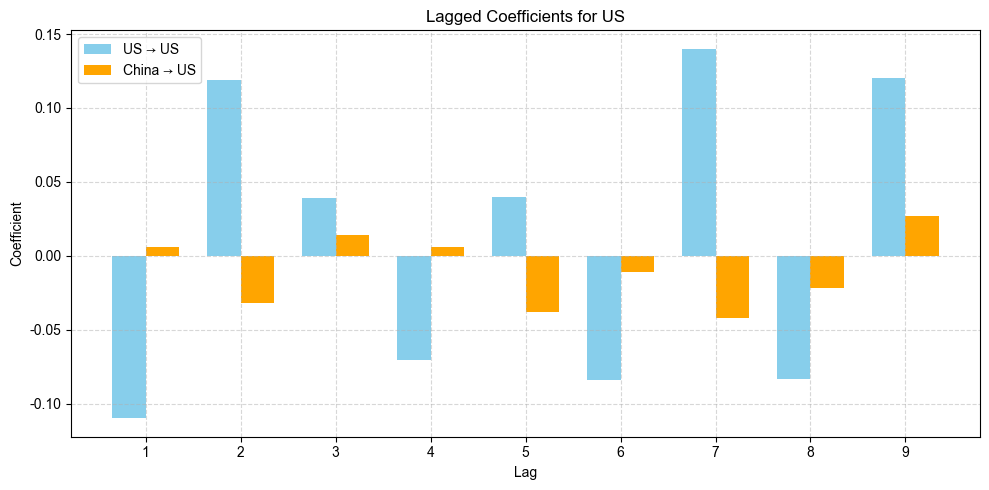

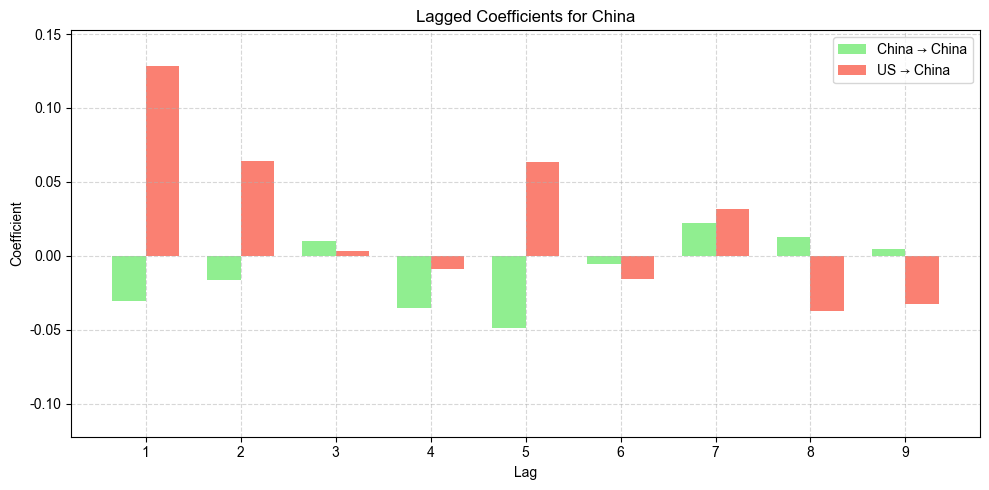

In [41]:
lags = np.arange(1, 10)
bar_width = 0.35

# 美国（第 0 行）
us_autocorr = coefs[:, 0, 0]
us_crosscorr = coefs[:, 0, 1]

# 中国（第 1 行）
china_autocorr = coefs[:, 1, 1]
china_crosscorr = coefs[:, 1, 0]

all_values = np.concatenate([us_autocorr, us_crosscorr, china_autocorr, china_crosscorr])
y_min, y_max = all_values.min(), all_values.max()
margin = 0.05 * (y_max - y_min)
y_lim = (y_min - margin, y_max + margin)

# 绘制美国图
plt.figure(figsize=(10, 5))
plt.bar(lags - bar_width/2, us_autocorr, width=bar_width, label='US → US', color='skyblue')
plt.bar(lags + bar_width/2, us_crosscorr, width=bar_width, label='China → US', color='orange')
plt.xlabel('Lag')
plt.ylabel('Coefficient')
plt.title('Lagged Coefficients for US')
plt.xticks(lags)
plt.ylim(y_lim)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 绘制中国图
plt.figure(figsize=(10, 5))
plt.bar(lags - bar_width/2, china_autocorr, width=bar_width, label='China → China', color='lightgreen')
plt.bar(lags + bar_width/2, china_crosscorr, width=bar_width, label='US → China', color='salmon')
plt.xlabel('Lag')
plt.xlabel('Lag')
plt.ylabel('Coefficient')
plt.title('Lagged Coefficients for China')
plt.xticks(lags)
plt.ylim(y_lim)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [28]:
residuals = var_model.resid  # DataFrame: shape (n_obs, n_vars)
resid_us = np.array(residuals.iloc[:, 0].tolist())  # 第一个变量的残差序列
resid_china = np.array(residuals.iloc[:, 1].tolist())  # 第二个变量的残差序列

In [29]:
test_serial_dependence(resid_us),test_serial_dependence(resid_china)

({'Ljung–Box Q Statistic': 1.2631857149448964,
  'Ljung–Box Q p-value': 0.9995031742788334,
  'ARCH LM Statistic': 311.2857827058347,
  'ARCH LM p-value': 6.378076946217504e-61},
 {'Ljung–Box Q Statistic': 0.04395943249897484,
  'Ljung–Box Q p-value': 0.9999999999580264,
  'ARCH LM Statistic': 19.104710162416655,
  'ARCH LM p-value': 0.038952684901695664})

## VCC-MGARCH

In [30]:
H, D, R, gar_us, gar_china = vcc_mgarch_fit_exp(resid_us, resid_china, 1, 1)
gar_us.params, gar_china.params

{'Ljung–Box Q Statistic': 27.284625731929708, 'Ljung–Box Q p-value': 0.002347421236908466, 'ARCH LM Statistic': 4.630339327354738, 'ARCH LM p-value': 0.9144659858276583}
{'Ljung–Box Q Statistic': 1.4645855639304968, 'Ljung–Box Q p-value': 0.9990414301156278, 'ARCH LM Statistic': 4.981620775012761, 'ARCH LM p-value': 0.8924023788884644}


(mu          0.026469
 omega       0.063740
 alpha[1]    0.146655
 beta[1]     0.808646
 Name: params, dtype: float64,
 mu         -0.007422
 omega       0.123311
 alpha[1]    0.099346
 beta[1]     0.832726
 Name: params, dtype: float64)

In [31]:
a_fit, b_fit, am1, am2 = fit_dcc_parameters(resid_us, resid_china)
H, D, R, _, _ = vcc_mgarch_fit_dcc(resid_us, resid_china, p=1, q=1, a=a_fit, b=b_fit)

{'Ljung–Box Q Statistic': 27.284625731929708, 'Ljung–Box Q p-value': 0.002347421236908466, 'ARCH LM Statistic': 4.630339327354738, 'ARCH LM p-value': 0.9144659858276583}
{'Ljung–Box Q Statistic': 1.4645855639304968, 'Ljung–Box Q p-value': 0.9990414301156278, 'ARCH LM Statistic': 4.981620775012761, 'ARCH LM p-value': 0.8924023788884644}
Optimal a = 0.0072, b = 0.9891, a + b = 0.9963


## 可视化

### 自相关

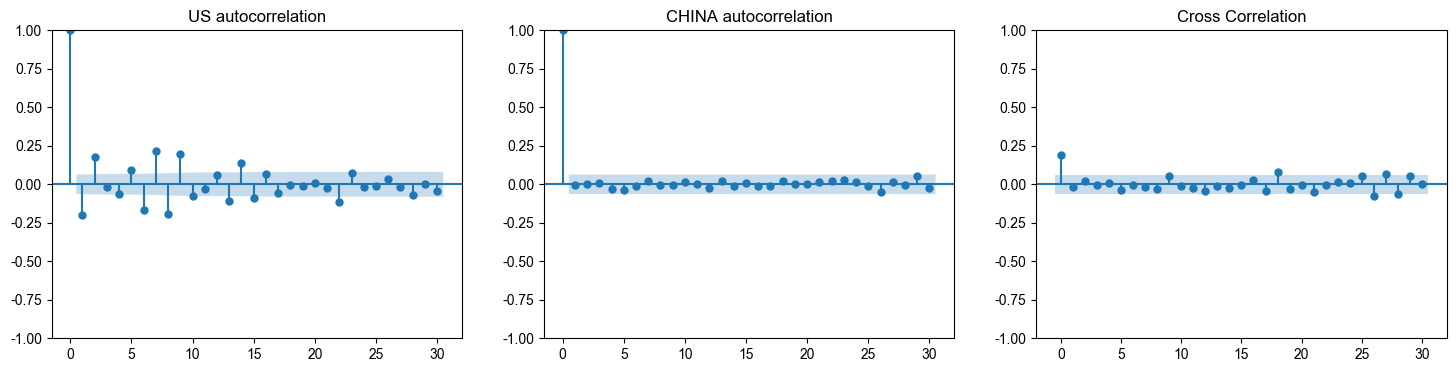

In [32]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, plot_ccf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
plot_acf(r_us, lags=30, ax=axes[0])
axes[0].set_title("US autocorrelation")
plot_acf(r_china, lags=30, ax=axes[1])
axes[1].set_title("CHINA autocorrelation")
plot_ccf(r_us, r_china, lags=30, ax=axes[2])
axes[2].set_title("Cross Correlation")
plt.show()

### 序列

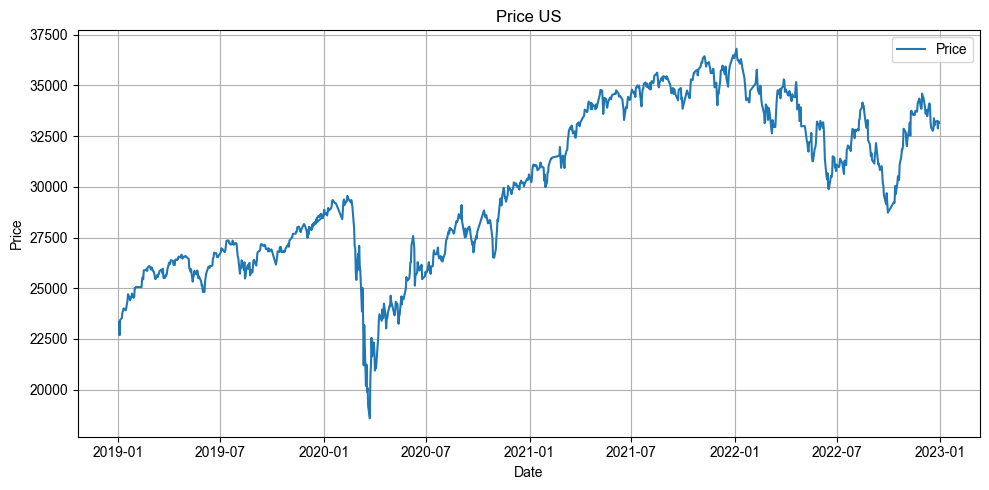

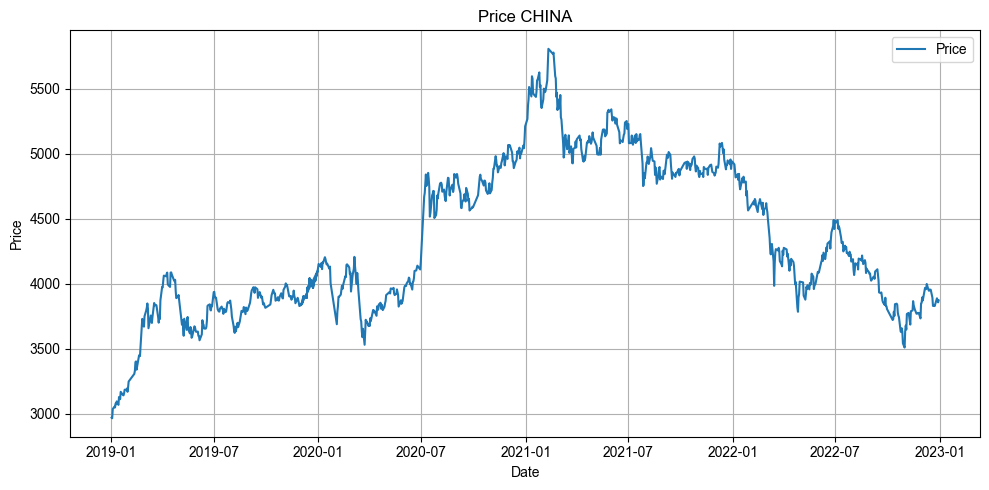

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(data_us.index, list_us, label='Price')
plt.title('Price US')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(data_china.index, list_china, label='Price')
plt.title('Price CHINA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 收益

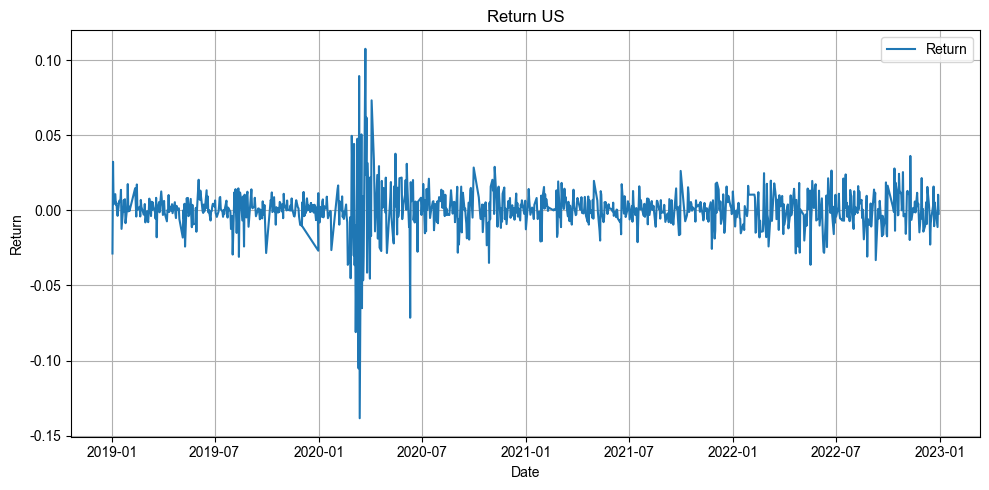

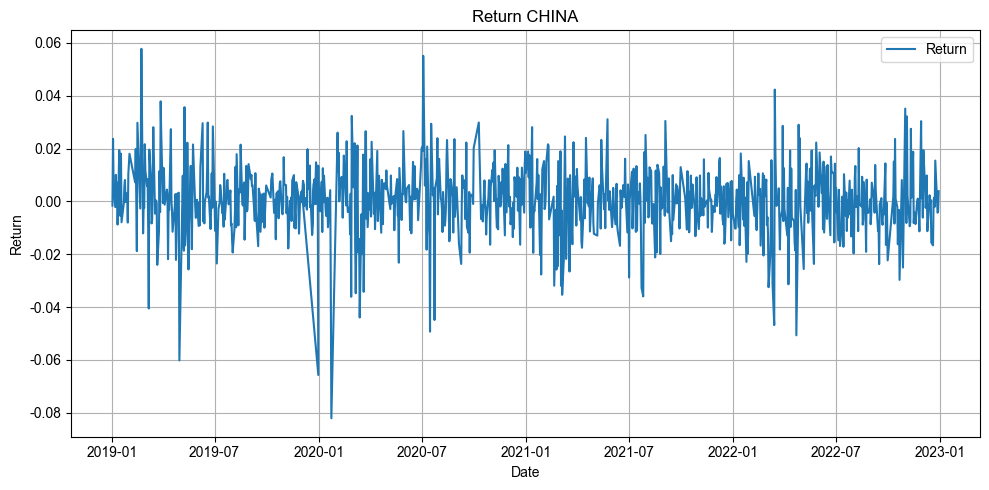

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(data_us.index[:-1], r_us, label='Return')
plt.title('Return US')
plt.xlabel('Date')
plt.ylabel('Return')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(data_china.index[:-1], r_china, label='Return')
plt.title('Return CHINA')
plt.xlabel('Date')
plt.ylabel('Return')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 残差

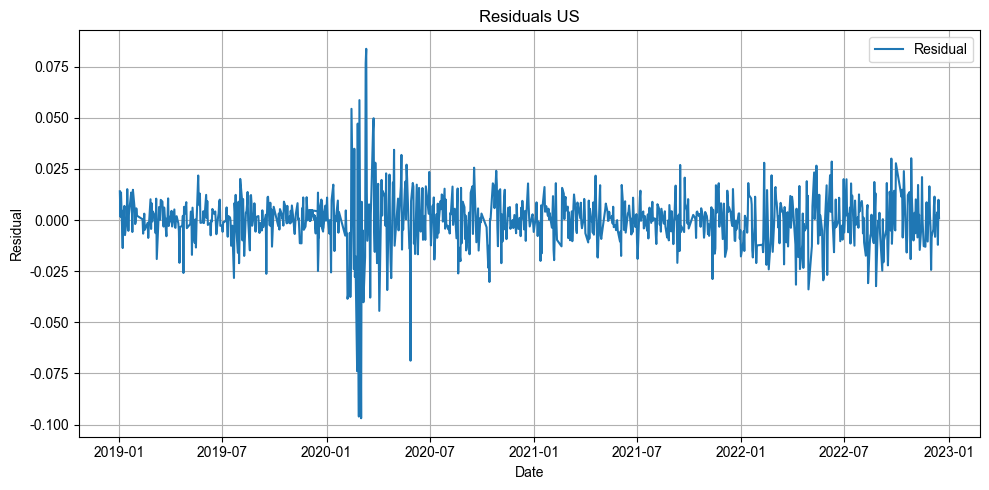

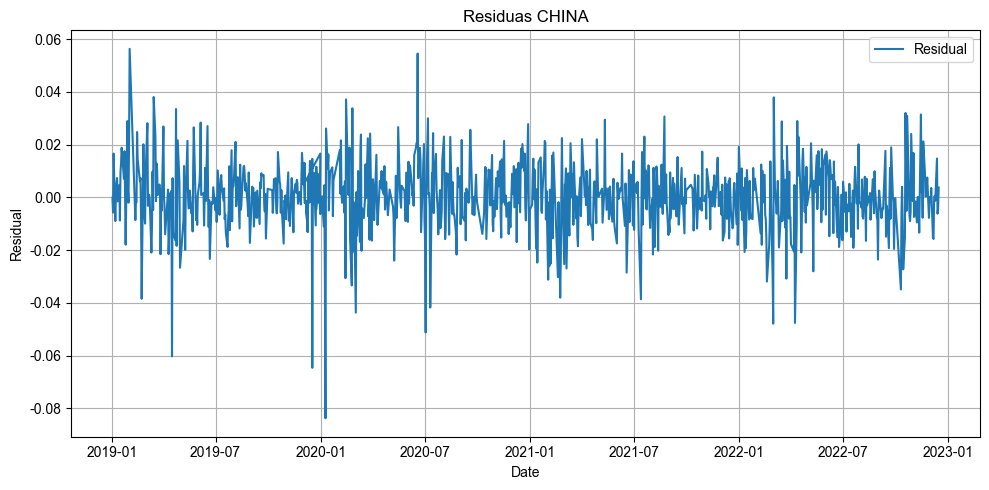

In [35]:
plt.figure(figsize=(10, 5))
plt.plot(data_us.index[:-(1+lag_order)], resid_us, label='Residual')
plt.title('Residuals US')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(data_china.index[:-(1+lag_order)], resid_china, label='Residual')
plt.title('Residuas CHINA')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### DCC-GARCH拟合结果

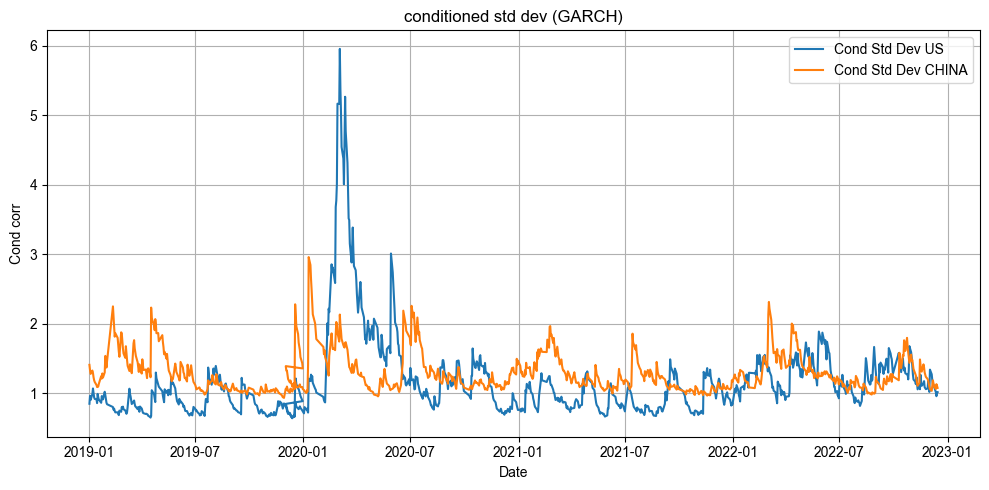

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(data_us.index[:-(1+lag_order)], D[:,0,0], label='Cond Std Dev US')
plt.plot(data_us.index[:-(1+lag_order)], D[:,1,1], label='Cond Std Dev CHINA')
plt.title("conditioned std dev (GARCH)")
plt.xlabel('Date')
plt.ylabel('Cond corr')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

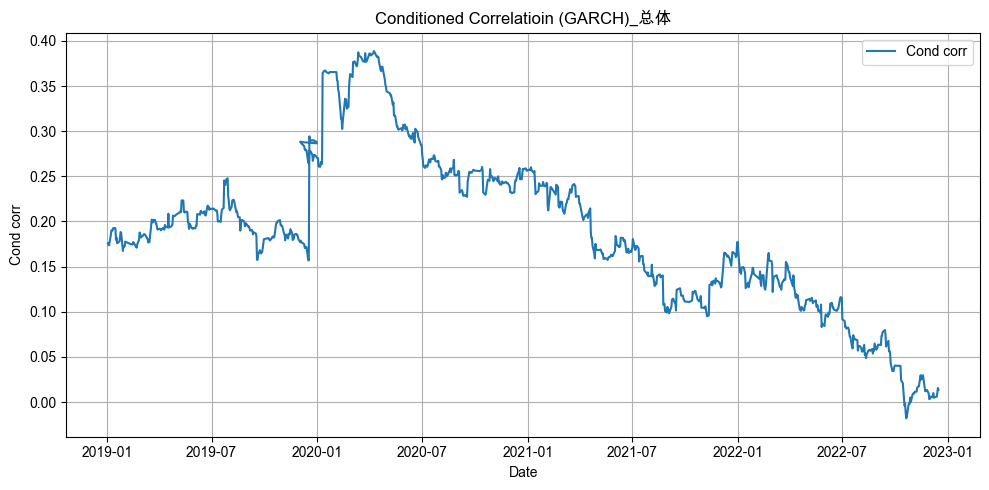

In [37]:
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'SimHei'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'Arial Unicode MS'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
    print('else!')
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(10, 5))
plt.plot(data_us.index[:-(1+lag_order)], R[:,0,1], label='Cond corr')
plt.title('Conditioned Correlatioin (GARCH)_'+name)
plt.xlabel('Date')
plt.ylabel('Cond corr')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()